# EE 467 Lab 2 (Extension): Breaking CAPTCHAs with PyTorch

In this extension notebook, we replicate the Deep Learning CAPTCHA breaking pipeline using **PyTorch**. 

We will perform the same preprocessing, training, and evaluation steps to demonstrate how to implement the Convolutional Neural Network (CNN) architecture defined in the original lab using PyTorch components.

In [1]:
# Install dependencies if needed
%pip install torch torchvision scikit-learn matplotlib opencv-python imutils

  Using cached torch-2.10.0-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp313-cp313-win_amd64.whl.metadata (5.4 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached torch-2.10.0-cp313-cp313-win_amd64.whl (113.8 MB)
Using cached torchvision-0.25.0-cp313-cp313-win_amd64.whl (4.3 MB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)

   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   ---------------------------------------- 0/3 [networkx]
   --------

## 1. Imports and Setup
We import standard libraries plus PyTorch (`torch`) modules.

In [2]:
import os
import cv2
import pickle
import numpy as np
from imutils import paths
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

# PyTorch Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Helper to verify device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Re-implementing helper functions locally to ensure standalone execution
def resize_to_fit(image, width, height):
    """ 
    Resize the image to fit within the specified width and height, 
    maintaining aspect ratio and padding the rest.
    """
    (h, w) = image.shape[:2]
    if w > h:
        image = cv2.resize(image, (width, int(h * width / w)))
    else:
        image = cv2.resize(image, (int(w * height / h), height))
        
    padW = int((width - image.shape[1]) / 2.0)
    padH = int((height - image.shape[0]) / 2.0)

    image = cv2.copyMakeBorder(image, padH, padH, padW, padW, cv2.BORDER_REPLICATE)
    image = cv2.resize(image, (width, height))
    return image

def print_images(images, texts, n_rows=2):
    """ Helper to display images """
    n_cols = len(images) // n_rows
    if len(images) % n_rows != 0: n_cols += 1
    plt.figure(figsize=(20, 5))
    for i, (img, text) in enumerate(zip(images, texts)):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(text)
        plt.axis('off')
    plt.show()

Using device: cpu


## 2. Preprocessing & Data Loading
This section mirrors the preprocessing logic from the TensorFlow lab. We load the raw CAPTCHAs, perform contour extraction to get individual characters, and prepare the dataset.

In [3]:
# Dataset config
CAPTCHA_IMAGE_FOLDER = "./captcha-images"
TVT_SPLIT_SEED = 31528476
CHAR_IMAGE_FOLDER = f"./char-images-{TVT_SPLIT_SEED}-pytorch"

# 1. Load Image Paths
if not os.path.exists(CAPTCHA_IMAGE_FOLDER):
    print("Extracting dataset...")
    !tar -xJf captcha-images.tar.xz

captcha_image_paths = list(paths.list_images(CAPTCHA_IMAGE_FOLDER))

def extract_captcha_text(image_path):
    return os.path.splitext(os.path.basename(image_path))[0]

captcha_texts = [extract_captcha_text(p) for p in captcha_image_paths]

# 2. Load and Preprocess Images
def load_transform_image(image_path):
    image = cv2.imread(image_path)
    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Add extra padding (8px)
    image_padded = cv2.copyMakeBorder(image_gray, 8, 8, 8, 8, cv2.BORDER_REPLICATE)
    return image_padded

captcha_images = [load_transform_image(p) for p in captcha_image_paths]

# 3. Split Dataset (Same random state for comparison)
captcha_images_tv, captcha_images_test, captcha_texts_tv, captcha_texts_test = train_test_split(
    captcha_images, captcha_texts, test_size=0.2, random_state=TVT_SPLIT_SEED
)

print(f"Train-validation set size: {len(captcha_images_tv)}")
print(f"Test set size: {len(captcha_images_test)}")

Train-validation set size: 908
Test set size: 228


## 3. Character Extraction
We use OpenCV contours to extract individual letters and separate conjoined letters.

In [4]:
def extract_chars(image):
    # Thresholding
    image_bw = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    contours = cv2.findContours(image_bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

    char_regions = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        # Split wide regions (conjoined letters)
        if w / h > 1.25:
            half_width = int(w / 2)
            char_regions.append((x, y, half_width, h))
            char_regions.append((x + half_width, y, half_width, h))
        else:
            char_regions.append((x, y, w, h))

    if len(char_regions) != 4:
        return None
    
    # Sort by X coordinate
    char_regions.sort(key=lambda x: x[0])
    
    char_images = []
    for x, y, w, h in char_regions:
        # Extract with 2px margin
        char_image = image[y - 2:y + h + 2, x - 2:x + w + 2]
        char_images.append(char_image)
    return char_images

def save_chars(char_images, captcha_text, save_dir, char_counts):
    for char_image, char in zip(char_images, captcha_text):
        save_path = os.path.join(save_dir, char)
        os.makedirs(save_path, exist_ok=True)
        char_count = char_counts.get(char, 1)
        char_image_path = os.path.join(save_path, f"{char_count}.png")
        cv2.imwrite(char_image_path, char_image)
        char_counts[char] = char_count + 1

char_counts = {}
# We extract only if folder doesn't exist, similar to lab logic
if not os.path.exists(CHAR_IMAGE_FOLDER):
    for image, text in zip(captcha_images_tv, captcha_texts_tv):
        chars = extract_chars(image)
        if chars:
            save_chars(chars, text, CHAR_IMAGE_FOLDER, char_counts)
    print("Character extraction complete.")
else:
    print("Character images already extracted.")

Character extraction complete.


## 4. PyTorch Data Preparation
Unlike TensorFlow which often uses `(Height, Width, Channels)`, PyTorch expects input tensors in the format `(Channels, Height, Width)`.

We also convert the One-Hot encoding from `LabelBinarizer` back to integer class indices because PyTorch's `CrossEntropyLoss` expects class indices.

In [5]:
def make_feature(image):
    # Resize to 20x20
    image = resize_to_fit(image, 20, 20)
    # Add channel dimension. 
    # In TF this was (20, 20, 1). In PyTorch we handle dimensions in the Dataset/Tensor conversion.
    return image

# Load features and labels
data = []
labels = []

for image_path in paths.list_images(CHAR_IMAGE_FOLDER):
    img = cv2.imread(image_path, cv2.COLOR_BGR2GRAY)
    img = make_feature(img)
    
    # Get label from folder name
    label = image_path.split(os.path.sep)[-2]
    
    data.append(img)
    labels.append(label)

# Scale to [0, 1]
data = np.array(data, dtype="float32") / 255.0

# TF shape: (N, 20, 20, 1) -> PyTorch shape: (N, 1, 20, 20)
# We add the channel dimension at index 1
data = np.expand_dims(data, axis=1)

# Encode labels
lb = LabelBinarizer()
labels_one_hot = lb.fit_transform(labels)
# Convert one-hot back to indices for PyTorch CrossEntropyLoss
labels_indices = np.argmax(labels_one_hot, axis=1)

# Train/Val Split
X_train, X_vali, y_train, y_vali = train_test_split(
    data, labels_indices, test_size=0.25, random_state=955996
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_vali)}")
print(f"Input shape: {X_train.shape}")  # Should be (N, 1, 20, 20)

# Convert to PyTorch Tensors and create DataLoaders
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
val_dataset = TensorDataset(torch.from_numpy(X_vali), torch.from_numpy(y_vali).long())

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Save label binarizer for decoding predictions later
with open("labels_pytorch.pkl", "wb") as f:
    pickle.dump(lb, f)

Training samples: 2685
Validation samples: 895
Input shape: (2685, 1, 20, 20)


## 5. Define PyTorch Model
We recreate the exact architecture from the TensorFlow lab:
1. Conv2D (20 filters, 5x5, padding=same) -> ReLU -> MaxPool (2x2)
2. Conv2D (50 filters, 5x5, padding=same) -> ReLU -> MaxPool (2x2)
3. Flatten
4. Dense (500) -> ReLU
5. Dense (Output)

In [6]:
class CaptchaNet(nn.Module):
    def __init__(self, n_classes):
        super(CaptchaNet, self).__init__()
        
        # Block 1
        # Input: (1, 20, 20)
        # Conv: 20 filters, 5x5 kernel. Padding=2 ensures 'same' output size (20x20)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2
        # Input after pool1: (20, 10, 10)
        # Conv: 50 filters, 5x5 kernel, padding=2 -> (50, 10, 10)
        self.conv2 = nn.Conv2d(in_channels=20, out_channels=50, kernel_size=5, padding=2)
        # After pool2: (50, 5, 5)
        
        # Fully Connected Layers
        # Flattened size: 50 * 5 * 5 = 1250
        self.fc1 = nn.Linear(50 * 5 * 5, 500)
        self.fc2 = nn.Linear(500, n_classes)
        
    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        
        # Block 2
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        # Flatten
        x = x.view(-1, 50 * 5 * 5)
        
        # FC 1
        x = F.relu(self.fc1(x))
        
        # Output (No Softmax needed, CrossEntropyLoss does it)
        x = self.fc2(x)
        return x

num_classes = len(lb.classes_)
model = CaptchaNet(num_classes).to(device)
print(model)

CaptchaNet(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=1250, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=32, bias=True)
)


## 6. Training
We use the **Adam** optimizer and **CrossEntropyLoss**.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 10

train_losses = []
val_accuracies = []

print("Starting Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    # Validation Loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    val_acc = correct / total
    train_losses.append(epoch_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f}")

print("Training Complete.")

# Save model state
torch.save(model.state_dict(), "captcha_model_pytorch.pth")

Starting Training...
Epoch 1/10 - Loss: 2.6917 - Val Acc: 0.7207
Epoch 2/10 - Loss: 0.3975 - Val Acc: 0.9475
Epoch 3/10 - Loss: 0.1229 - Val Acc: 0.9777
Epoch 4/10 - Loss: 0.0604 - Val Acc: 0.9765
Epoch 5/10 - Loss: 0.0385 - Val Acc: 0.9821
Epoch 6/10 - Loss: 0.0193 - Val Acc: 0.9810
Epoch 7/10 - Loss: 0.0084 - Val Acc: 0.9777
Epoch 8/10 - Loss: 0.0072 - Val Acc: 0.9821
Epoch 9/10 - Loss: 0.0057 - Val Acc: 0.9832
Epoch 10/10 - Loss: 0.0018 - Val Acc: 0.9821
Training Complete.


## 7. Evaluation Pipeline
Now we test the full end-to-end pipeline: Input Test CAPTCHA -> Segment -> Predict -> Result.

In [8]:
# Load model
model = CaptchaNet(num_classes).to(device)
model.load_state_dict(torch.load("captcha_model_pytorch.pth"))
model.eval()

# Dummy char for failures (4 chars, 1 channel, 20x20)
DUMMY_CHAR_IMAGES = np.zeros((4, 1, 20, 20), dtype="float32")

extract_failed_indices = []
test_data = []

# 1. Preprocess Test Data
for i, captcha_image in enumerate(captcha_images_test):
    char_images = extract_chars(captcha_image)
    
    if char_images:
        # Process extracted chars
        processed_chars = []
        for char in char_images:
            feat = make_feature(char) # 20x20
            feat = feat / 255.0       # Scale
            processed_chars.append(feat)
        
        # Stack to (4, 20, 20) then add channel -> (4, 1, 20, 20)
        batch = np.array(processed_chars, dtype="float32")
        batch = np.expand_dims(batch, axis=1)
        test_data.append(batch)
    else:
        extract_failed_indices.append(i)
        test_data.append(DUMMY_CHAR_IMAGES)

# 2. Run Inference
predictions = []
with torch.no_grad():
    for i, batch_images in enumerate(test_data):
        # If extraction failed, mark as failure immediately
        if i in extract_failed_indices:
            predictions.append("-")
            continue
            
        # Convert to tensor
        batch_tensor = torch.from_numpy(batch_images).to(device)
        
        # Predict (Batch of 4 characters)
        outputs = model(batch_tensor)
        _, preds = torch.max(outputs, 1)
        
        # Decode using LabelBinarizer classes
        pred_chars = [lb.classes_[idx] for idx in preds.cpu().numpy()]
        pred_text = "".join(pred_chars)
        predictions.append(pred_text)

# 3. Calculate Accuracy
n_correct = 0
correct_indices = []
incorrect_indices = []

for i, (pred, actual) in enumerate(zip(predictions, captcha_texts_test)):
    if pred == actual:
        n_correct += 1
        if len(correct_indices) < 10: correct_indices.append(i)
    else:
        if len(incorrect_indices) < 10: incorrect_indices.append(i)

print(f"# Test CAPTCHAs: {len(captcha_texts_test)}")
print(f"# Correct: {n_correct}")
print(f"Accuracy: {n_correct / len(captcha_texts_test):.4f}")

# Test CAPTCHAs: 228
# Correct: 213
Accuracy: 0.9342


## 8. Visualization
Comparing correct and incorrect predictions.

Correct Predictions:


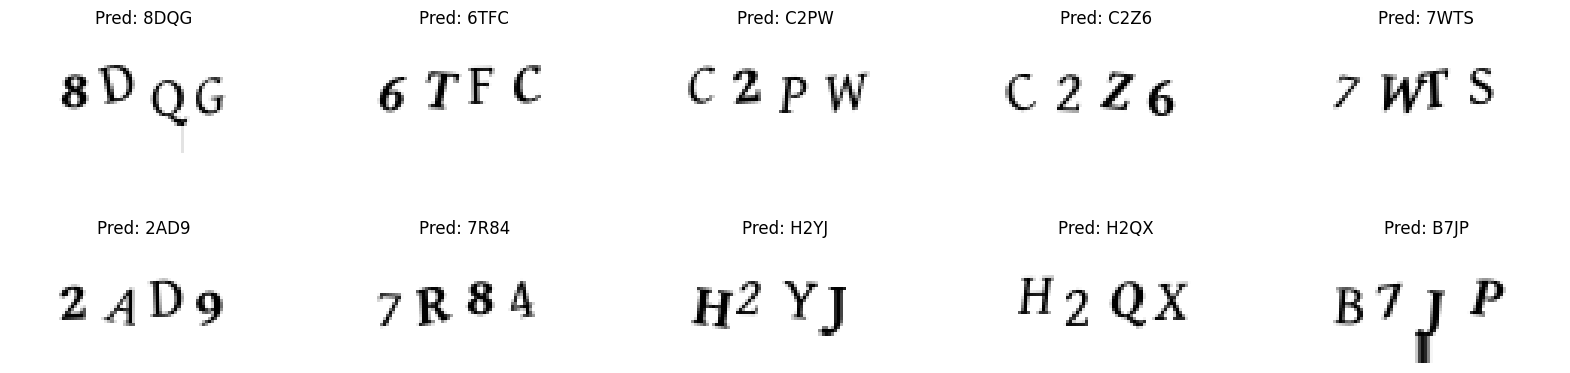

Incorrect Predictions:


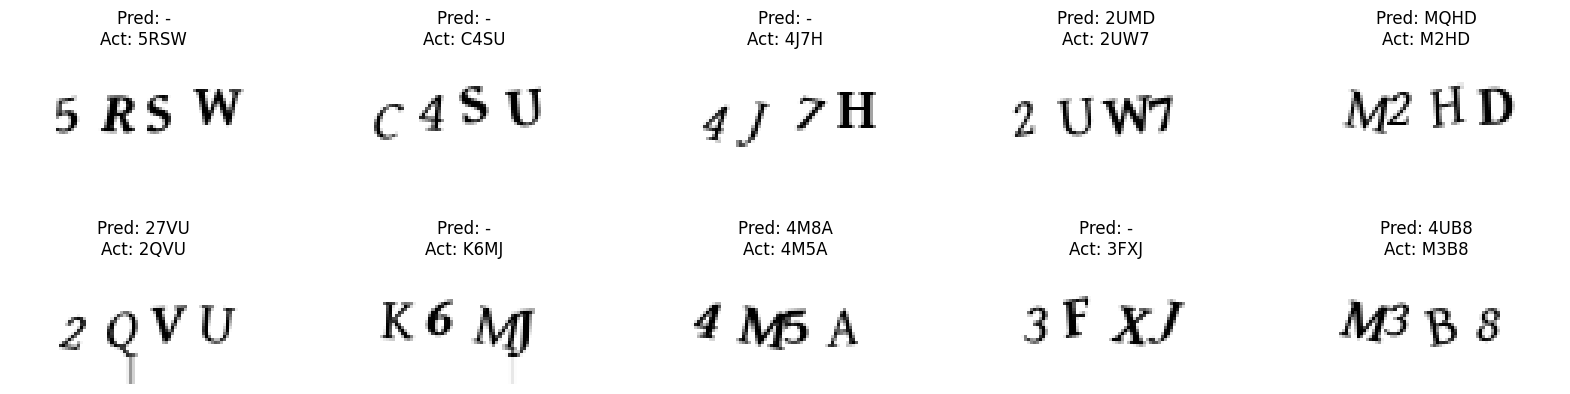

In [9]:
print("Correct Predictions:")
print_images(
    [captcha_images_test[i] for i in correct_indices],
    texts=[f"Pred: {predictions[i]}" for i in correct_indices]
)

print("Incorrect Predictions:")
print_images(
    [captcha_images_test[i] for i in incorrect_indices],
    texts=[f"Pred: {predictions[i]}\nAct: {captcha_texts_test[i]}" for i in incorrect_indices]
)